#  Мини-проект — Machine Learning
## Прогнозирование оттока клиентов телекоммуникационной компании

**Датасет:** IBM Telco Customer Churn  
**Тип задачи:** Binary Classification  
**Target:** `Churn`

---

###  Цель проекта

Цель проекта — построить модель машинного обучения, которая сможет предсказывать, уйдёт ли клиент телекоммуникационной компании.

Целевая переменная `Churn` принимает два значения:

- `No` — клиент остался;
- `Yes` — клиент ушёл.

Прогнозирование оттока имеет практическую ценность для бизнеса. Если компания заранее определит клиентов с высоким риском ухода, она сможет предложить им специальные условия, скидки или дополнительную поддержку.

В проекте будут сравнены Logistic Regression, Decision Tree, Random Forest и Gradient Boosting. Для лучшей модели будет выполнен подбор гиперпараметров с помощью Optuna.

# 1. Выбор датасета и постановка задачи

Для проекта используется реальный датасет **IBM Telco Customer Churn**.

Датасет содержит информацию о клиентах телекоммуникационной компании: демографические характеристики, используемые услуги, тип контракта, способ оплаты, ежемесячные и общие платежи.

**Источник данных:**  
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Датасет содержит более 7000 наблюдений и более 20 признаков.

### Задача

Необходимо решить задачу бинарной классификации и предсказать значение `Churn`:

- `0` — клиент остаётся;
- `1` — клиент уходит.

### Практическая ценность

Модель позволит выявлять клиентов с повышенным риском оттока. Компания сможет использовать прогноз для проведения программ удержания клиентов и снижения финансовых потерь.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn (1).csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Точное имя загруженного файла
filename = list(uploaded.keys())[0]

print("Загруженный файл:", filename)

df = pd.read_csv(filename)

print("Размер датасета:", df.shape)
print("Churn exists:", "Churn" in df.columns)

df.head()

Загруженный файл: WA_Fn-UseC_-Telco-Customer-Churn (1).csv
Размер датасета: (7043, 21)
Churn exists: True


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Количество дубликатов:", df.duplicated().sum())

print("\nПропущенные значения:")
print(df.isna().sum())

print("\nТип TotalCharges:", df["TotalCharges"].dtype)

empty_total = (
    df["TotalCharges"]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Пустых значений TotalCharges:", empty_total)

Количество дубликатов: 0

Пропущенные значения:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Тип TotalCharges: object
Пустых значений TotalCharges: 11


### Вывод по первичному анализу

Датасет не содержит полных дубликатов. Стандартная проверка `isna()` также не обнаружила пропущенных значений.

Однако дополнительная проверка показала, что столбец `TotalCharges` имеет тип `object`, хотя должен содержать числовые значения. В нём обнаружено **11 пустых строк**, которые стандартная проверка пропусков не определила как `NaN`.

Перед дальнейшим анализом необходимо преобразовать `TotalCharges` в числовой формат и обработать появившиеся пропуски.

In [6]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Новый тип:", df["TotalCharges"].dtype)
print("Пропусков:", df["TotalCharges"].isna().sum())

Новый тип: float64
Пропусков: 11


In [7]:
df = df.dropna(subset=["TotalCharges"]).copy()

print("Размер после очистки:", df.shape)
print("Всего пропусков:", df.isna().sum().sum())

Размер после очистки: (7032, 21)
Всего пропусков: 0


### Вывод по очистке

Столбец `TotalCharges` был преобразован из типа `object` в числовой формат. После преобразования обнаружилось 11 пропущенных значений.

Поскольку это очень небольшая часть датасета, строки с пропусками были удалены. После очистки осталось **7032 наблюдения**, пропущенные значения отсутствуют.

In [8]:
churn_counts = df["Churn"].value_counts()
churn_percent = df["Churn"].value_counts(normalize=True) * 100

print("Количество:")
print(churn_counts)

print("\nПроценты:")
print(churn_percent.round(2))

Количество:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Проценты:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


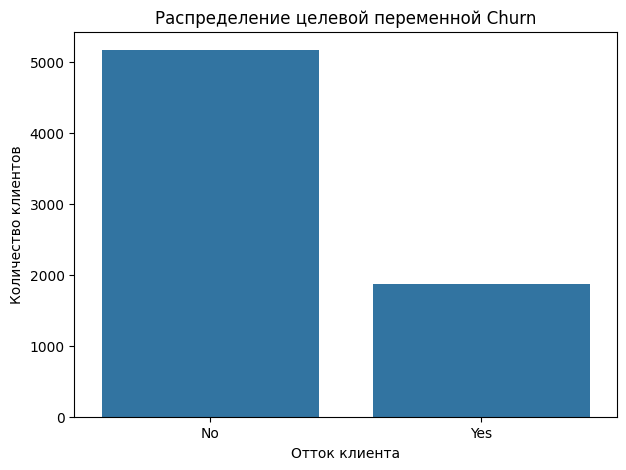

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Распределение целевой переменной Churn")
plt.xlabel("Отток клиента")
plt.ylabel("Количество клиентов")

plt.show()

### Вывод

Целевая переменная `Churn` имеет дисбаланс классов: клиентов, которые остались в компании, значительно больше, чем клиентов, которые ушли.

Это важно учитывать при построении модели. Поэтому помимо Accuracy необходимо оценивать Precision, Recall, F1-score и ROC-AUC.

Позже будет дополнительно проверено использование `class_weight="balanced"` для повышения качества определения клиентов с оттоком.

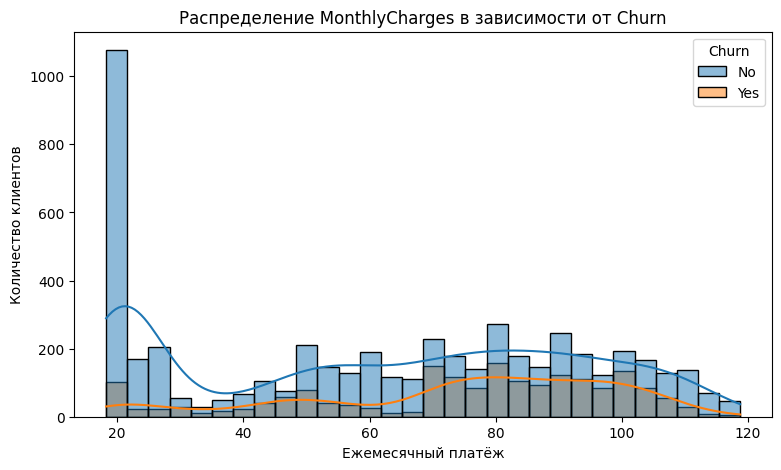

In [10]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Распределение MonthlyCharges в зависимости от Churn")
plt.xlabel("Ежемесячный платёж")
plt.ylabel("Количество клиентов")

plt.show()

### Вывод

Распределение `MonthlyCharges` различается между клиентами, которые ушли и остались. Это указывает на то, что размер ежемесячного платежа потенциально может быть полезным признаком при прогнозировании оттока.

При этом по одному признаку нельзя сделать вывод о причине ухода клиента — необходимо учитывать остальные характеристики одновременно.

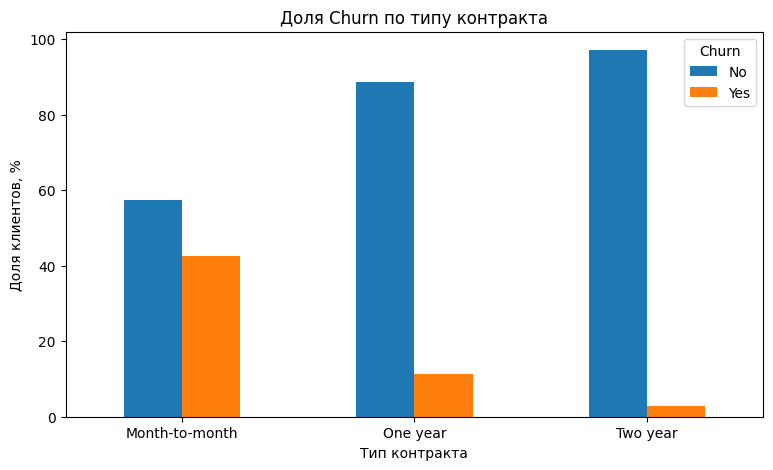

In [11]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Доля Churn по типу контракта")
plt.xlabel("Тип контракта")
plt.ylabel("Доля клиентов, %")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

### Вывод

Доля оттока заметно различается между типами контрактов. Особенно важно обратить внимание на клиентов с помесячными контрактами (`Month-to-month`), поскольку структура оттока в этой группе отличается от клиентов с долгосрочными контрактами.

Следовательно, `Contract` является потенциально важным признаком для модели прогнозирования Churn.

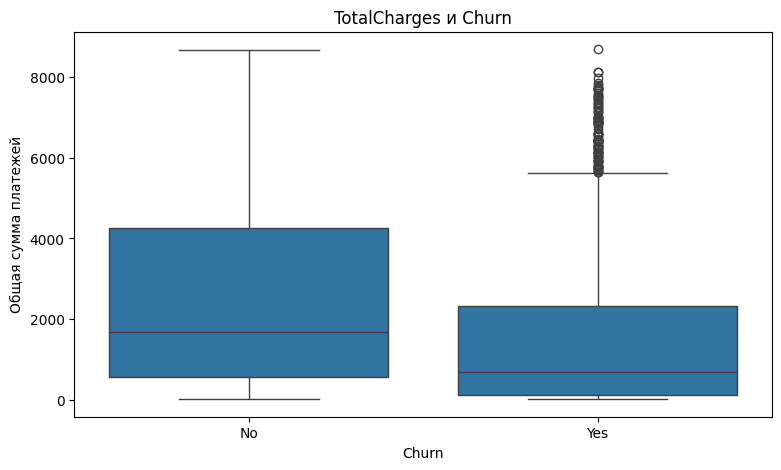

In [12]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("TotalCharges и Churn")
plt.xlabel("Churn")
plt.ylabel("Общая сумма платежей")

plt.show()

In [13]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30
std,24.55,30.09,2266.77
min,1.00,18.25,18.80
25%,9.00,35.59,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.86,3794.74
max,72.00,118.75,8684.80


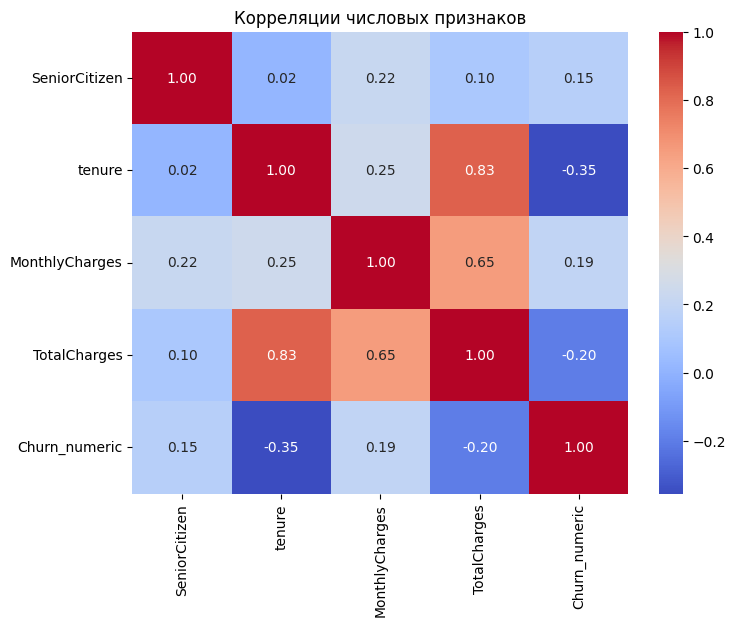

In [14]:
eda_numeric = df[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
].copy()

eda_numeric["Churn_numeric"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

plt.figure(figsize=(8, 6))

sns.heatmap(
    eda_numeric.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Корреляции числовых признаков")

plt.show()

### Вывод

Тепловая карта позволяет оценить направление и силу линейных связей между числовыми признаками и оттоком.

Особенно важно учитывать связь `tenure`, `MonthlyCharges` и `TotalCharges`, а также то, что высокая корреляция между признаками не означает причинно-следственную связь.

# 3. Feature Engineering и Pipeline

На этом этапе данные будут подготовлены для машинного обучения.

Целевая переменная — `Churn`:

- `0` — клиент остался;
- `1` — клиент ушёл.

`customerID` исключается, поскольку является уникальным идентификатором и не несёт полезной информации для прогнозирования.

Данные сначала разделяются на обучающую и тестовую выборки. Все операции предобработки выполняются внутри `Pipeline`, чтобы избежать утечки данных (data leakage).

In [15]:
# Target
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Features
X = df.drop(columns=["Churn", "customerID"])

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (7032, 19)
y shape: (7032,)

Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nTrain target:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest target:")
print(y_test.value_counts(normalize=True).round(3))

Train: (5625, 19)
Test: (1407, 19)

Train target:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64

Test target:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64


In [17]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    col for col in X.columns
    if col not in numeric_features
]

print("Числовые признаки:")
print(numeric_features)

print("\nКатегориальные признаки:")
print(categorical_features)

Числовые признаки:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Категориальные признаки:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Numeric preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

# Combine transformations
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Pipeline предобработки создан.")

Pipeline предобработки создан.


### Вывод

Числовые и категориальные признаки обрабатываются раздельно с помощью `ColumnTransformer`.

Для числовых признаков используется заполнение возможных пропусков медианой и стандартизация через `StandardScaler`. Для категориальных признаков используется заполнение наиболее частым значением и кодирование через `OneHotEncoder`.

Предобработка будет выполняться внутри `Pipeline` после разделения данных на Train и Test. Это предотвращает использование информации из тестовой выборки при обучении и снижает риск **data leakage**.

# 4. Baseline-модель — Logistic Regression

В качестве базовой модели используется Logistic Regression.

Baseline необходим как точка отсчёта: результаты более сложных моделей будут сравниваться с её качеством.

In [19]:
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

print("Baseline Logistic Regression обучена.")

Baseline Logistic Regression обучена.


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

baseline_pred = baseline_model.predict(X_test)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)
baseline_roc_auc = roc_auc_score(y_test, baseline_proba)

print("=== Logistic Regression Baseline ===")
print("Accuracy:", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall:", baseline_recall)
print("F1-score:", baseline_f1)
print("ROC-AUC:", baseline_roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, baseline_pred))

print("\nClassification Report:")
print(classification_report(y_test, baseline_pred))

=== Logistic Regression Baseline ===
Accuracy: 0.8038379530916845
Precision: 0.6484848484848484
Recall: 0.5721925133689839
F1-score: 0.6079545454545454
ROC-AUC: 0.8359290473207676

Confusion Matrix:
[[917 116]
 [160 214]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



### Вывод по Baseline-модели

Базовая модель Logistic Regression показала следующие результаты:

- **Accuracy:** 80.38%
- **Precision:** 64.85%
- **Recall:** 57.22%
- **F1-score:** 60.80%
- **ROC-AUC:** 83.59%

Модель правильно классифицирует около **80% клиентов**, а значение ROC-AUC показывает достаточно хорошую способность разделять клиентов с оттоком и без него.

Однако Recall для класса `Churn = 1` составляет только **57.22%**. Из 374 клиентов, которые действительно ушли, модель правильно обнаружила 214, но пропустила 160.

Эти результаты будут использоваться как точка отсчёта для сравнения с более сложными моделями.

# 5. Сравнение моделей

Для сравнения будут обучены три модели:

1. Decision Tree
2. Random Forest
3. XGBoost

Все модели используют одинаковое разделение Train/Test и одинаковый Pipeline предобработки.

Качество оценивается по одинаковым метрикам: Accuracy, Precision, Recall, F1-score и ROC-AUC.

In [22]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, proba)
    }

    return metrics

In [23]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

dt_metrics = evaluate_model(
    "Decision Tree",
    decision_tree,
    X_train,
    X_test,
    y_train,
    y_test
)

dt_metrics

{'Model': 'Decision Tree',
 'Accuracy': 0.7306325515280739,
 'Precision': 0.493368700265252,
 'Recall': 0.49732620320855614,
 'F1': 0.49533954727030627,
 'ROC_AUC': np.float64(0.6564546438129947)}

In [24]:
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_metrics = evaluate_model(
    "Random Forest",
    random_forest,
    X_train,
    X_test,
    y_train,
    y_test
)

rf_metrics

{'Model': 'Random Forest',
 'Accuracy': 0.7903340440653873,
 'Precision': 0.6357388316151202,
 'Recall': 0.4946524064171123,
 'F1': 0.556390977443609,
 'ROC_AUC': np.float64(0.8127941047051577)}

In [26]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_metrics = evaluate_model(
    "XGBoost",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_metrics

{'Model': 'XGBoost',
 'Accuracy': 0.7917555081734187,
 'Precision': 0.6261682242990654,
 'Recall': 0.5374331550802139,
 'F1': 0.5784172661870504,
 'ROC_AUC': np.float64(0.8345572057917596)}

In [27]:
baseline_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": baseline_accuracy,
    "Precision": baseline_precision,
    "Recall": baseline_recall,
    "F1": baseline_f1,
    "ROC_AUC": baseline_roc_auc
}

comparison = pd.DataFrame([
    baseline_metrics,
    dt_metrics,
    rf_metrics,
    xgb_metrics
])

comparison = comparison.sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.8038,0.6485,0.5722,0.6080,0.8359
1,XGBoost,0.7918,0.6262,0.5374,0.5784,0.8346
2,Random Forest,0.7903,0.6357,0.4947,0.5564,0.8128
3,Decision Tree,0.7306,0.4934,0.4973,0.4953,0.6565


### Вывод по сравнению моделей

Были сравнены четыре модели классификации на одной и той же тестовой выборке.

Лучший результат показала **Logistic Regression**:

- Accuracy — **80.38%**
- Precision — **64.85%**
- Recall — **57.22%**
- F1-score — **60.80%**
- ROC-AUC — **83.59%**

XGBoost показал очень близкий ROC-AUC — **83.46%**, однако его Accuracy, Recall и F1-score оказались немного ниже.

Random Forest показал ROC-AUC **81.28%**, а базовое Decision Tree продемонстрировало наиболее слабый результат — ROC-AUC **65.65%**.

Таким образом, увеличение сложности модели само по себе не гарантирует улучшение качества. На данном этапе Logistic Regression остаётся лучшей моделью по совокупности метрик.

# 6. Подбор гиперпараметров с Optuna

По результатам сравнения лучшей моделью оказалась Logistic Regression с ROC-AUC = 0.8359.

Для оптимизации её гиперпараметров используется Optuna. Будет выполнено 30 попыток (trials), а качество будет оцениваться с помощью кросс-валидации по метрике ROC-AUC.

In [28]:
!pip -q install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 13.0 MB/s eta 0:00:00


In [29]:
import optuna

from sklearn.model_selection import cross_val_score

In [30]:
def objective(trial):

    C = trial.suggest_float(
        "C",
        0.001,
        100,
        log=True
    )

    penalty = trial.suggest_categorical(
        "penalty",
        ["l1", "l2"]
    )

    class_weight = trial.suggest_categorical(
        "class_weight",
        [None, "balanced"]
    )

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            C=C,
            penalty=penalty,
            class_weight=class_weight,
            solver="liblinear",
            max_iter=2000,
            random_state=42
        ))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )

    return scores.mean()

In [31]:
optuna.logging.set_verbosity(
    optuna.logging.WARNING
)

study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=30
)

print("Лучший ROC-AUC на CV:")
print(study.best_value)

print("\nЛучшие параметры:")
print(study.best_params)

Лучший ROC-AUC на CV:
0.8462498076720626

Лучшие параметры:
{'C': 18.980165385869846, 'penalty': 'l2', 'class_weight': None}


### Вывод по подбору гиперпараметров

Optuna выполнила **30 попыток** подбора гиперпараметров Logistic Regression с использованием 5-fold cross-validation.

Лучшее среднее значение **ROC-AUC на кросс-валидации составило 0.8463**.

Оптимальные параметры:

- `C ≈ 18.98`
- `penalty = l2`
- `class_weight = None`

Optuna не выбрала балансировку классов как оптимальный вариант по ROC-AUC. Далее лучшая конфигурация будет обучена на всей обучающей выборке и один раз оценена на отложенной тестовой выборке.

# 7. Финальная оценка модели

Финальная модель обучается с гиперпараметрами, найденными Optuna.

Тестовая выборка не использовалась при подборе параметров и применяется только для финальной оценки качества.

In [32]:
best_params = study.best_params

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=best_params["C"],
        penalty=best_params["penalty"],
        class_weight=best_params["class_weight"],
        solver="liblinear",
        max_iter=2000,
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)
final_proba = final_model.predict_proba(X_test)[:, 1]

print("Финальная модель обучена.")

Финальная модель обучена.


In [33]:
final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred)
final_recall = recall_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)
final_roc_auc = roc_auc_score(y_test, final_proba)

print("=== FINAL MODEL ===")
print("Accuracy:", final_accuracy)
print("Precision:", final_precision)
print("Recall:", final_recall)
print("F1-score:", final_f1)
print("ROC-AUC:", final_roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))

print("\nClassification Report:")
print(classification_report(y_test, final_pred))

=== FINAL MODEL ===
Accuracy: 0.8002842928216063
Precision: 0.6388059701492538
Recall: 0.5721925133689839
F1-score: 0.6036671368124118
ROC-AUC: 0.8351162959243366

Confusion Matrix:
[[912 121]
 [160 214]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1033
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.73      0.74      1407
weighted avg       0.79      0.80      0.80      1407



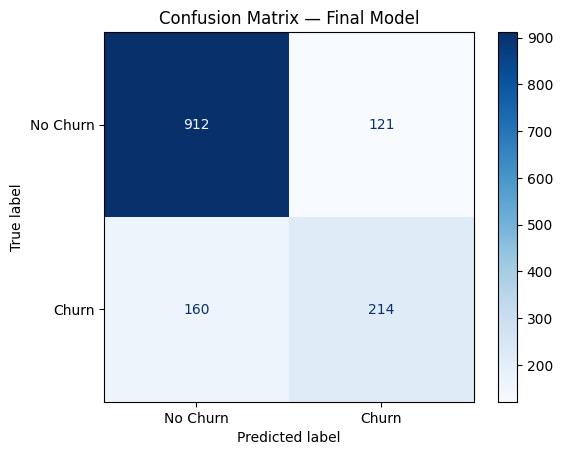

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred,
    display_labels=["No Churn", "Churn"],
    cmap="Blues"
)

plt.title("Confusion Matrix — Final Model")
plt.show()

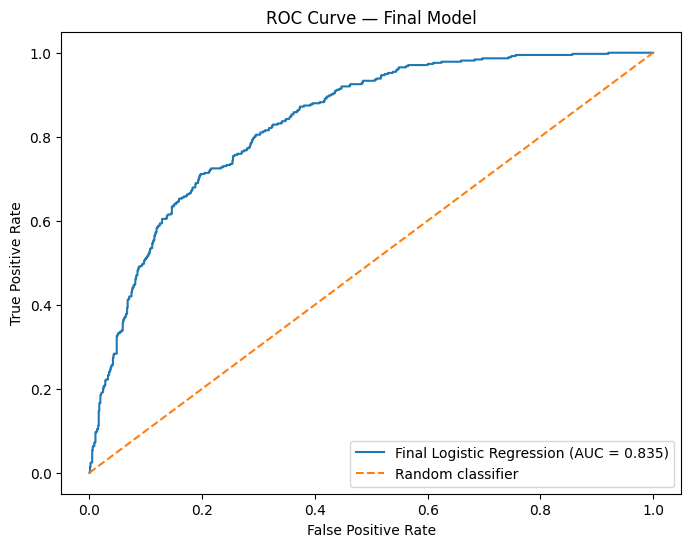

In [35]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    final_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Final Logistic Regression (AUC = {final_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Model")
plt.legend()
plt.show()

In [36]:
improvement = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc_auc
    ],
    "Final Model": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc
    ]
})

improvement["Difference"] = (
    improvement["Final Model"]
    - improvement["Baseline"]
)

improvement.round(4)

,Metric,Baseline,Final Model,Difference
0,Accuracy,0.8038,0.8003,-0.0036
1,Precision,0.6485,0.6388,-0.0097
2,Recall,0.5722,0.5722,0.0000
3,F1,0.6080,0.6037,-0.0043
4,ROC-AUC,0.8359,0.8351,-0.0008


### Сравнение Baseline и модели после Optuna

Optuna улучшила средний ROC-AUC на кросс-валидации до **0.8463**, однако на отложенной тестовой выборке заметного улучшения не произошло.

Результаты на тестовой выборке:

- Accuracy: **0.8038 → 0.8003**
- Precision: **0.6485 → 0.6388**
- Recall: **0.5722 → 0.5722**
- F1-score: **0.6080 → 0.6037**
- ROC-AUC: **0.8359 → 0.8351**

Таким образом, подобранные Optuna параметры показали хорошие результаты при кросс-валидации, но не смогли превзойти baseline Logistic Regression на тестовой выборке.

Различия между моделями очень небольшие, поэтому можно сделать вывод, что исходная Logistic Regression уже была хорошо настроена для данного датасета. Этот результат также показывает, почему качество модели необходимо оценивать на отдельной тестовой выборке, а не только по результатам кросс-валидации.

# 8. Bonus — работа с дисбалансом классов

В данных наблюдается дисбаланс целевой переменной: клиентов без оттока значительно больше, чем клиентов с `Churn = 1`.

Для проверки влияния дисбаланса обучим Logistic Regression с параметром `class_weight="balanced"` и сравним её с baseline.

In [37]:
balanced_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

balanced_model.fit(X_train, y_train)

balanced_pred = balanced_model.predict(X_test)
balanced_proba = balanced_model.predict_proba(X_test)[:, 1]

balanced_accuracy = accuracy_score(y_test, balanced_pred)
balanced_precision = precision_score(y_test, balanced_pred)
balanced_recall = recall_score(y_test, balanced_pred)
balanced_f1 = f1_score(y_test, balanced_pred)
balanced_roc_auc = roc_auc_score(y_test, balanced_proba)

print("=== BALANCED LOGISTIC REGRESSION ===")
print("Accuracy:", balanced_accuracy)
print("Precision:", balanced_precision)
print("Recall:", balanced_recall)
print("F1-score:", balanced_f1)
print("ROC-AUC:", balanced_roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, balanced_pred))

=== BALANCED LOGISTIC REGRESSION ===
Accuracy: 0.7256574271499645
Precision: 0.4901315789473684
Recall: 0.7967914438502673
F1-score: 0.6069246435845214
ROC-AUC: 0.8351344145860403

Confusion Matrix:
[[723 310]
 [ 76 298]]


In [38]:
balance_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc_auc
    ],
    "Balanced": [
        balanced_accuracy,
        balanced_precision,
        balanced_recall,
        balanced_f1,
        balanced_roc_auc
    ]
})

balance_comparison["Difference"] = (
    balance_comparison["Balanced"]
    - balance_comparison["Baseline"]
)

balance_comparison.round(4)

,Metric,Baseline,Balanced,Difference
0,Accuracy,0.8038,0.7257,-0.0782
1,Precision,0.6485,0.4901,-0.1584
2,Recall,0.5722,0.7968,0.2246
3,F1,0.6080,0.6069,-0.0010
4,ROC-AUC,0.8359,0.8351,-0.0008


### Вывод по работе с дисбалансом классов

Использование `class_weight="balanced"` существенно изменило поведение модели.

Главное улучшение произошло в **Recall**, который вырос с **57.22% до 79.68%**. Таким образом, сбалансированная модель обнаруживает значительно большую долю клиентов, которые действительно уходят.

При этом:

- Accuracy снизилась с **80.38% до 72.57%**;
- Precision снизилась с **64.85% до 49.01%**;
- F1-score практически не изменился: **60.80% → 60.69%**;
- ROC-AUC также практически не изменился.

Это демонстрирует компромисс между Precision и Recall. Сбалансированная модель обнаруживает больше клиентов с реальным оттоком, но одновременно создаёт больше ложных срабатываний.

С точки зрения бизнеса такой вариант может быть полезен, если **стоимость потери клиента выше стоимости дополнительного предложения клиенту, который на самом деле не собирался уходить**. В этом случае более высокий Recall является важным преимуществом.

# 9. Итоговый вывод

В проекте была решена задача прогнозирования оттока клиентов на реальном датасете **IBM Telco Customer Churn**.

В ходе EDA была обнаружена проблема со столбцом `TotalCharges`: он имел строковый тип и содержал 11 скрытых пустых значений. Данные были очищены, а анализ целевой переменной показал заметный дисбаланс классов.

Для предотвращения утечки данных числовые и категориальные признаки обрабатывались внутри `Pipeline` и `ColumnTransformer`. В качестве baseline использовалась Logistic Regression, которая показала **Accuracy 80.38%, F1-score 60.80% и ROC-AUC 83.59%**.

Дополнительно были обучены Decision Tree, Random Forest и XGBoost. Среди исходных моделей лучший результат по ROC-AUC показала **Logistic Regression**, немного опередив XGBoost.

Для Logistic Regression был выполнен подбор гиперпараметров с помощью **Optuna с 30 trials и 5-fold cross-validation**. Лучший CV ROC-AUC составил **0.8463**, однако на тестовой выборке оптимизированная модель не превзошла baseline. Это показывает, что улучшение результатов кросс-валидации не всегда приводит к улучшению на новых данных.

Дополнительно был исследован дисбаланс классов с помощью `class_weight="balanced"`. Recall для клиентов с оттоком вырос с **57.22% до 79.68%**, однако Accuracy и Precision снизились. Такой вариант может быть полезен бизнесу, если основной приоритет — обнаружить как можно больше клиентов с риском ухода.

Таким образом, **обычная Logistic Regression остаётся наиболее сбалансированной моделью по совокупности метрик**, а версия с `class_weight="balanced"` является альтернативой для сценария, где особенно важно минимизировать количество пропущенных клиентов с оттоком.

При наличии дополнительного времени проект можно улучшить за счёт более широкого поиска гиперпараметров, настройки порога классификации, создания дополнительных признаков и проверки других ансамблевых моделей.